# 12 — Label audit: how wrong is `y = 0`?

nb11 reported that 43 % of its matched `y = 0` controls had at least one registered clinical trial. That number was a by-product of the validation design, not a census: the control group was matched to high-scoring predictions on popularity, so it sampled famous compounds and common diseases. Read as a property of the dataset it would be badly misleading.

This notebook measures contamination properly — on a stratified sample of the negative population — and answers three questions the modelling notebooks cannot:

1. **Does contamination depend on model score?** If high-scoring `y = 0` pairs are more contaminated than low-scoring ones, then AUPRC is not merely noisy — it is biased downward exactly where the metric carries most of its weight.
2. **What happens to the metric under a different label definition?** Every number in nb05–nb10 counts unrecorded true positives as false positives. §5 shows why the obvious correction is not the "ceiling" it looks like.
3. **Which negatives can we actually trust?** Hard-negative mining is currently unsafe (nb11 §8). A screened negative set is what unblocks it.

## Sampling design

Screening all 41,112 test-set `y = 0` pairs would mean ~41 k requests to a public registry. Instead we take a **stratified sample with known inclusion probabilities**, weighted toward the high-score region where the answer matters most, and reweight to population estimates.

| Score decile (GCN, among test `y = 0`) | Sampled | Why |
|---|---|---|
| 10 (top) | 1000 | Drives precision@K and most of AUPRC's mass |
| 9 | 400 | Transition region |
| 1–8 | 200 each | Establishes the background contamination rate |

Roughly 3,000 requests, cached to `artifacts/external/` alongside nb11's cache.

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, pickle, time, urllib.parse, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART = pathlib.Path("artifacts")
EXT = ART / "external"; EXT.mkdir(parents=True, exist_ok=True)
HETIONET_CUTOFF = "2017-01-01"

meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_test = split["idx_test"]
SEED = int(meta["split_seed"])
rng = np.random.default_rng(SEED)
y = pairs["y"].to_numpy()

gcn = pd.read_parquet(ART / "predictions" / "gcn.parquet")
score_gcn = gcn["score_gcn"].to_numpy()

y_test = y[idx_test]
s_test = score_gcn[idx_test]
AUPRC_MEASURED = average_precision_score(y_test, s_test)
AUROC_MEASURED = roc_auc_score(y_test, s_test)
print(f"Test pairs {len(idx_test):,} | positives {int(y_test.sum())} | negatives {int((y_test==0).sum()):,}")
print(f"GCN as measured against Hetionet labels: AUROC {AUROC_MEASURED:.4f}, AUPRC {AUPRC_MEASURED:.4f}")


Test pairs 41,263 | positives 151 | negatives 41,112
GCN as measured against Hetionet labels: AUROC 0.9218, AUPRC 0.1787


In [2]:
t0 = time.time()
hetnet = load_hetnet()
cname = {n["identifier"]: n["name"] for n in hetnet["nodes"] if n["kind"] == "Compound"}
dname = {n["identifier"]: n["name"] for n in hetnet["nodes"] if n["kind"] == "Disease"}
print(f"Loaded hetnet in {time.time() - t0:.1f}s")

test = pairs.iloc[idx_test].copy()
test["score"] = s_test
test["cn"] = test["compound"].map(cname)
test["dn"] = test["disease"].map(dname)
test = test.reset_index(drop=True)
neg = test[test["y"] == 0].copy()
print(f"Test-set negatives to audit: {len(neg):,}")


Loaded hetnet in 13.2s
Test-set negatives to audit: 41,112


## 2 · Registry client

Same cache file as nb11, so anything already queried there is free. The cache doubles as a pinned snapshot of the registry — re-running this notebook later reproduces these numbers even as ClinicalTrials.gov grows.

In [3]:
API = "https://clinicaltrials.gov/api/v2/studies"
CACHE_FILE = EXT / "ctgov_pair_cache.pkl"
_cache: dict = pickle.loads(CACHE_FILE.read_bytes()) if CACHE_FILE.exists() else {}
print(f"Cache entries carried over from nb11: {len(_cache):,}")


def _get(url: str, retries: int = 3):
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=30) as r:
                return json.load(r)
        except Exception:
            if attempt == retries - 1:
                return None
            time.sleep(1.5 * (attempt + 1))
    return None


def query_marginal(term: str, field: str) -> int:
    key = (field, term.lower())
    if key in _cache:
        return _cache[key]
    d = _get(f"{API}?query.{field}={urllib.parse.quote(term)}&pageSize=1&countTotal=true&format=json")
    _cache[key] = int(d.get("totalCount", 0)) if d else 0
    return _cache[key]


def query_pair(drug: str, cond: str) -> dict:
    key = (drug.lower(), cond.lower())
    if key in _cache:
        return _cache[key]
    url = (f"{API}?query.intr={urllib.parse.quote(drug)}&query.cond={urllib.parse.quote(cond)}"
           "&pageSize=200&countTotal=true&format=json&fields=NCTId,Phase,StartDate")
    d = _get(url)
    if d is None:
        out = {"n_trials": np.nan, "n_trials_post": np.nan, "max_phase": None}
    else:
        studies = d.get("studies", [])
        n_post, phases = 0, []
        for s in studies:
            ps = s.get("protocolSection", {})
            sd = ps.get("statusModule", {}).get("startDateStruct", {}).get("date", "")
            if sd and sd >= HETIONET_CUTOFF:
                n_post += 1
            phases.extend(ps.get("designModule", {}).get("phases", []))
        rk = {"PHASE1": 1, "PHASE2": 2, "PHASE3": 3, "PHASE4": 4}
        best = max((rk.get(p, 0) for p in phases), default=0)
        out = {"n_trials": int(d.get("totalCount", 0)), "n_trials_post": n_post,
               "max_phase": {0: None, 1: "PHASE1", 2: "PHASE2", 3: "PHASE3", 4: "PHASE4"}[best]}
    _cache[key] = out
    return out


Cache entries carried over from nb11: 6,424


## 3 · Draw the stratified sample

In [4]:
N_DECILES = 10
neg = neg.sort_values("score", ascending=False).reset_index(drop=True)
neg["decile"] = pd.qcut(neg["score"], N_DECILES, labels=False, duplicates="drop") + 1
# decile 10 = highest GCN scores, decile 1 = lowest

plan = {10: 1000, 9: 400}
for d in range(1, 9):
    plan[d] = 200

frames = []
for d, n_take in sorted(plan.items()):
    grp = neg[neg["decile"] == d]
    take = min(n_take, len(grp))
    picked = grp.sample(take, random_state=SEED)
    picked = picked.assign(n_in_decile=len(grp), n_sampled=take,
                           weight=len(grp) / take)      # inverse inclusion probability
    frames.append(picked)

sample = pd.concat(frames).reset_index(drop=True)
print(f"Sampled {len(sample):,} of {len(neg):,} negatives "
      f"({len(sample) / len(neg):.1%}), stratified by GCN score decile")
sample.groupby("decile").agg(pool=("n_in_decile", "first"), sampled=("n_sampled", "first"),
                             weight=("weight", "first"),
                             score_min=("score", "min"), score_max=("score", "max")).round(3)


Sampled 3,000 of 41,112 negatives (7.3%), stratified by GCN score decile


,pool,sampled,weight,score_min,score_max
decile,,,,,
1,4112,200,20.560,-91.556,-25.973
2,4111,200,20.555,-25.916,-20.118
3,4111,200,20.555,-20.083,-16.438
4,4111,200,20.555,-16.409,-13.844
5,4111,200,20.555,-13.824,-11.741
6,4111,200,20.555,-11.727,-9.893
7,4111,200,20.555,-9.880,-8.167
8,4111,200,20.555,-8.156,-6.318
9,4111,400,10.278,-6.304,-3.454


In [5]:
# Screen the sample. ~3k requests at roughly 0.07 s each; instant on re-run.
t0 = time.time()
recs = []
for i, r in enumerate(sample.itertuples(index=False), 1):
    recs.append(query_pair(r.cn, r.dn))
    if i % 500 == 0:
        print(f"  screened {i}/{len(sample)}  ({time.time() - t0:.0f}s)")
res = pd.DataFrame(recs, index=sample.index)
sample = pd.concat([sample, res], axis=1)

# Marginals, needed for the defensible-negative definition in section 6
sample["drug_marginal"] = [query_marginal(x, "intr") for x in sample["cn"]]
sample["cond_marginal"] = [query_marginal(x, "cond") for x in sample["dn"]]
CACHE_FILE.write_bytes(pickle.dumps(_cache))
print(f"Screening done in {time.time() - t0:.0f}s. Cache now {len(_cache):,} entries.")


  screened 500/3000  (0s)
  screened 1000/3000  (0s)
  screened 1500/3000  (0s)
  screened 2000/3000  (0s)
  screened 2500/3000  (0s)
  screened 3000/3000  (0s)
Screening done in 0s. Cache now 6,424 entries.


## 4 · Is contamination score-dependent?

This is the question that determines whether AUPRC is merely understated or *structurally* biased. A flat contamination rate across deciles would mean the labels are uniformly noisy — annoying, but it would shift every method equally. A rate that climbs with score means the model is being penalised precisely for its most confident calls.

In [6]:
def flag(df):
    out = df.copy()
    out["has_any"]   = out["n_trials"] > 0
    out["has_ph2"]   = out["max_phase"].isin(["PHASE2", "PHASE3", "PHASE4"])
    out["has_10"]    = out["n_trials"] >= 10
    out["has_post"]  = out["n_trials_post"] > 0
    return out

sample = flag(sample)

by_dec = (sample.groupby("decile")
          .agg(n_sampled=("has_any", "size"),
               pool=("n_in_decile", "first"),
               pct_any=("has_any", "mean"),
               pct_ph2=("has_ph2", "mean"),
               pct_10=("has_10", "mean"),
               median_score=("score", "median"))
          .sort_index(ascending=False))
for c in ("pct_any", "pct_ph2", "pct_10"):
    by_dec[c] = (100 * by_dec[c]).round(1)
by_dec


,n_sampled,pool,pct_any,pct_ph2,pct_10,median_score
decile,,,,,,
10,1000,4112,28.3,23.8,6.8,-0.830510
9,400,4111,12.8,10.2,1.8,-4.969253
8,200,4111,11.0,7.5,1.5,-7.164921
7,200,4111,10.0,6.5,2.0,-8.917797
6,200,4111,9.5,8.5,1.0,-10.694952
5,200,4111,10.0,8.5,1.5,-12.591464
4,200,4111,11.5,8.0,1.5,-14.893892
3,200,4111,9.0,6.0,2.5,-17.858765
2,200,4111,9.5,7.0,2.0,-22.215656


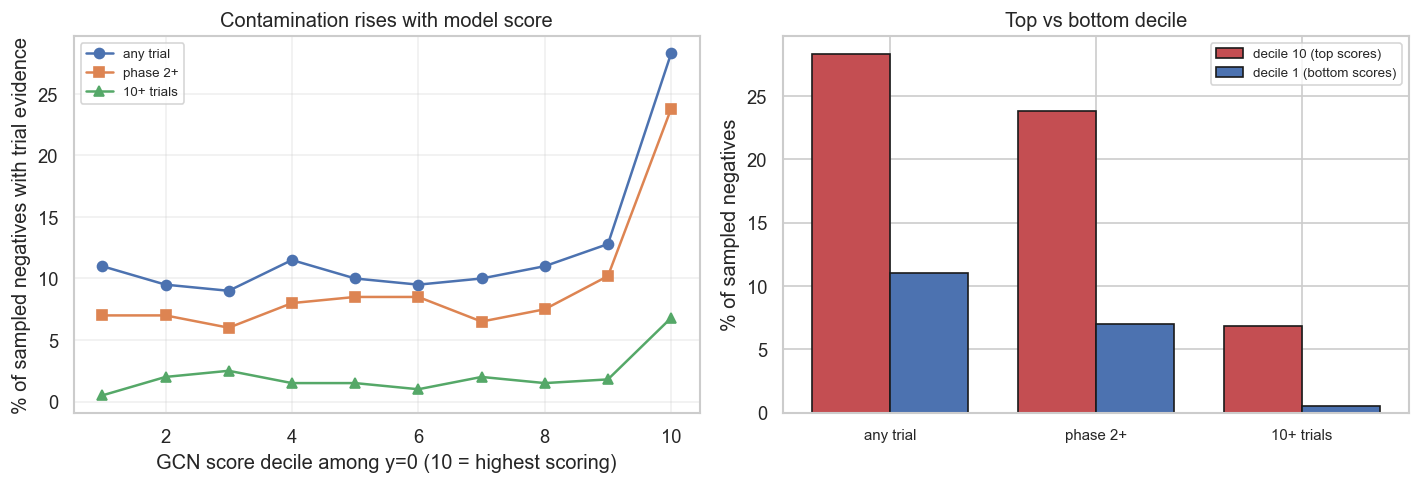

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

d = by_dec.sort_index()
axes[0].plot(d.index, d["pct_any"], marker="o", label="any trial")
axes[0].plot(d.index, d["pct_ph2"], marker="s", label="phase 2+")
axes[0].plot(d.index, d["pct_10"],  marker="^", label="10+ trials")
axes[0].set(xlabel="GCN score decile among y=0 (10 = highest scoring)",
            ylabel="% of sampled negatives with trial evidence",
            title="Contamination rises with model score")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

top, bottom = by_dec.loc[10], by_dec.loc[1]
labels = ["any trial", "phase 2+", "10+ trials"]
x = np.arange(3); w = 0.38
axes[1].bar(x - w/2, [top["pct_any"], top["pct_ph2"], top["pct_10"]], w,
            label="decile 10 (top scores)", color="C3", edgecolor="k")
axes[1].bar(x + w/2, [bottom["pct_any"], bottom["pct_ph2"], bottom["pct_10"]], w,
            label="decile 1 (bottom scores)", color="C0", edgecolor="k")
axes[1].set(xticks=x, ylabel="% of sampled negatives", title="Top vs bottom decile")
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].legend(fontsize=8)
plt.tight_layout()


In [8]:
# Population estimate via inverse-probability weighting
w = sample["weight"].values
for lab, col in [("any trial", "has_any"), ("phase 2+", "has_ph2"), ("10+ trials", "has_10")]:
    v = sample[col].values.astype(float)
    est = float((v * w).sum() / w.sum())
    print(f"Estimated share of ALL {len(neg):,} test negatives with {lab:11s}: {est:.1%}")
print()
r10, r1 = by_dec.loc[10, "pct_ph2"], by_dec.loc[1, "pct_ph2"]
print(f"Phase 2+ contamination, top decile {r10:.1f}% vs bottom decile {r1:.1f}%  "
      f"(ratio {r10 / max(r1, 1e-9):.1f}x)")


Estimated share of ALL 41,112 test negatives with any trial  : 12.3%
Estimated share of ALL 41,112 test negatives with phase 2+   : 9.3%
Estimated share of ALL 41,112 test negatives with 10+ trials : 2.1%

Phase 2+ contamination, top decile 23.8% vs bottom decile 7.0%  (ratio 3.4x)


## 5 · Two label definitions, two different tasks

The obvious move is to call the measured AUPRC a floor, relabel the evidenced pairs as positive, and quote the result as a ceiling. That framing is wrong, and the numbers below show why.

Adding positives does not simply raise the score. It changes what is being asked:

- **Hetionet labels** ask *how well does the model rank the 151 held-out `treats` edges?*
- **Evidence labels** ask *how well does the model rank every pair with phase 2+ trial support?*

The second set is far larger and includes many pairs the model scores in the middle of the distribution. A model tuned to the first question is not automatically good at the second. Both numbers are real; they answer different questions, and neither bounds the other.

In [9]:
B = 200
rates = sample.groupby("decile")["has_ph2"].mean().to_dict()

score_all  = test["score"].values
y_hetionet = test["y"].values.copy()
neg_row_idx = test.index[test["y"] == 0].values

screened     = {(r.cn, r.dn): bool(r.has_ph2) for r in sample.itertuples(index=False)}
is_screened  = np.array([(c, d) in screened for c, d in zip(neg["cn"], neg["dn"])])
screened_val = np.array([screened.get((c, d), False) for c, d in zip(neg["cn"], neg["dn"])])
p_dec = np.array([rates.get(dd, 0.0) for dd in neg["decile"].values])

boot, n_added = np.empty(B), np.empty(B)
rng2 = np.random.default_rng(SEED)
for b in range(B):
    flip = np.where(is_screened, screened_val, rng2.random(len(neg)) < p_dec)
    y_star = y_hetionet.copy()
    y_star[neg_row_idx[flip]] = 1
    n_added[b] = flip.sum()
    boot[b] = average_precision_score(y_star, score_all)

base_het = y_hetionet.mean()
base_ev  = (y_hetionet.sum() + n_added.mean()) / len(y_hetionet)

print("Task A - rank Hetionet held-out treats edges")
print(f"  positives {int(y_hetionet.sum())}  ({base_het:.2%} of test set)")
print(f"  AUPRC {AUPRC_MEASURED:.4f}   lift over random {AUPRC_MEASURED / base_het:.1f}x")
print()
print("Task B - rank every pair with phase 2+ trial evidence")
print(f"  positives {int(y_hetionet.sum())} recorded + ~{int(n_added.mean()):,} evidenced "
      f"({base_ev:.2%} of test set)")
print(f"  AUPRC {boot.mean():.4f}   95% MC [{np.percentile(boot, 2.5):.4f}, "
      f"{np.percentile(boot, 97.5):.4f}]   lift over random {boot.mean() / base_ev:.1f}x")


Task A - rank Hetionet held-out treats edges
  positives 151  (0.37% of test set)
  AUPRC 0.1787   lift over random 48.8x

Task B - rank every pair with phase 2+ trial evidence
  positives 151 recorded + ~3,824 evidenced (9.63% of test set)
  AUPRC 0.1115   95% MC [0.1074, 0.1164]   lift over random 1.2x


### 5a · The imputation has a bias built into it

The Monte Carlo above draws each unscreened pair's status from its decile's rate, which quietly assumes the model cannot discriminate *within* a decile. If that assumption is false, the procedure manufactures unrankable positives and deflates Task B.

Test it directly on the screened data, where the labels are observed rather than imputed.

In [10]:
from scipy import stats

print("Within-decile discrimination — does score still separate evidenced pairs?")
for dec in (10, 9, 5, 1):
    g = sample[sample["decile"] == dec]
    if len(g) < 100 or not g["has_ph2"].any():
        continue
    hi = g[g["score"] >= g["score"].median()]
    lo = g[g["score"] <  g["score"].median()]
    _, pv = stats.mannwhitneyu(g.loc[g["has_ph2"], "score"],
                               g.loc[~g["has_ph2"], "score"], alternative="greater")
    verdict = "discriminates" if pv < 0.05 else "flat"
    print(f"  decile {dec:>2} (n={len(g):>4}): upper half {hi['has_ph2'].mean():5.1%} vs "
          f"lower half {lo['has_ph2'].mean():5.1%}   p={pv:.3f}   {verdict}")


Within-decile discrimination — does score still separate evidenced pairs?
  decile 10 (n=1000): upper half 31.0% vs lower half 16.6%   p=0.000   discriminates
  decile  9 (n= 400): upper half  8.0% vs lower half 12.5%   p=0.735   flat
  decile  5 (n= 200): upper half  5.0% vs lower half 12.0%   p=0.934   flat
  decile  1 (n= 200): upper half  5.0% vs lower half  9.0%   p=0.825   flat


In [11]:
# Direct estimate: no imputation, inverse-probability weights make it population-representative
w_s = sample["weight"].values
auprc_direct = average_precision_score(sample["has_ph2"].astype(int), sample["score"],
                                       sample_weight=w_s)
base_direct = float(np.average(sample["has_ph2"].astype(float), weights=w_s))
lift_direct = auprc_direct / base_direct

print("Task B, estimated two ways")
print(f"  Monte Carlo (imputed)     AUPRC {boot.mean():.4f}  baseline {base_ev:.2%}  "
      f"lift {boot.mean() / base_ev:.2f}x")
print(f"  Direct, IPW-weighted      AUPRC {auprc_direct:.4f}  baseline {base_direct:.2%}  "
      f"lift {lift_direct:.2f}x   <-- preferred")
print()
print("The direct estimate uses observed labels only and makes no within-decile assumption.")


Task B, estimated two ways
  Monte Carlo (imputed)     AUPRC 0.1115  baseline 9.63%  lift 1.16x
  Direct, IPW-weighted      AUPRC 0.1975  baseline 9.31%  lift 2.12x   <-- preferred

The direct estimate uses observed labels only and makes no within-decile assumption.


The top decile does discriminate internally — among its 1,000 screened pairs, the upper half carries roughly twice the phase 2+ rate of the lower half. The imputation therefore understates Task B, and the **direct inverse-probability-weighted estimate is the one to quote**.



**Compare the lifts, not the raw AUPRCs.** The random baseline moves with the label set, so the two AUPRC values are not on a common scale. Lift over the relevant baseline is.

The gap between the lifts is the finding: the model is sharply tuned to Hetionet's notion of *treats*, and much weaker as a general detector of "somebody ran an efficacy trial on this pair". That is consistent with nb11, where enrichment appeared for phase 2+ evidence but was modest in absolute terms. The graph taught it a narrower relation than the registry records.

## 6 · A negative set we can defend

For hard-negative mining we need pairs that are negative for a *reason*, not merely unrecorded. The criterion:

- `y = 0` in Hetionet, **and**
- zero registered trials joining the two, **and**
- the compound is itself well studied (≥ 50 trials overall — the median), **and**
- the disease is itself well studied (≥ 100 trials overall)

The last two conditions are what turn an absence into evidence. If a drug with hundreds of trials and a disease with thousands have never once been tested together across the registry's history, that silence is informative. Without them, a zero mostly reflects that nobody studies the compound at all.

In [12]:
DRUG_MIN, COND_MIN = 50, 100

sample["defensible_neg"] = (
    (sample["n_trials"] == 0)
    & (sample["drug_marginal"] >= DRUG_MIN)
    & (sample["cond_marginal"] >= COND_MIN)
)
sample["coverage_gap"] = (
    (sample["n_trials"] == 0)
    & ((sample["drug_marginal"] < DRUG_MIN) | (sample["cond_marginal"] < COND_MIN))
)

n_def = int(sample["defensible_neg"].sum())
n_gap = int(sample["coverage_gap"].sum())
n_cont = int(sample["has_any"].sum())
print(f"Of {len(sample):,} screened negatives:")
print(f"  contaminated (has trial evidence) : {n_cont:5,}  ({n_cont/len(sample):.1%})")
print(f"  defensible negative               : {n_def:5,}  ({n_def/len(sample):.1%})")
print(f"  coverage gap (uninformative zero) : {n_gap:5,}  ({n_gap/len(sample):.1%})")
print()
est_def = float((sample["defensible_neg"].values * sample["weight"].values).sum()
                / sample["weight"].values.sum())
print(f"Reweighted to the full test set, roughly {est_def:.0%} of the "
      f"{len(neg):,} negatives ({int(est_def*len(neg)):,} pairs) qualify as defensible.")


Of 3,000 screened negatives:
  contaminated (has trial evidence) :   497  (16.6%)
  defensible negative               : 1,134  (37.8%)
  coverage gap (uninformative zero) : 1,369  (45.6%)

Reweighted to the full test set, roughly 36% of the 41,112 negatives (14,681 pairs) qualify as defensible.


### 6a · Safe hard-negative candidates

The pairs below score highly *and* survive the screen. These are what nb08's random negative sampler should be drawing from: cases where the model is confident and the outside world offers no support. They are the informative mistakes.

In [13]:
hard_negs = (sample[sample["defensible_neg"]]
             .sort_values("score", ascending=False)
             [["cn", "dn", "score", "decile", "drug_marginal", "cond_marginal"]]
             .head(20).reset_index(drop=True))
hard_negs.columns = ["compound", "disease", "gcn_score", "decile", "drug_trials", "disease_trials"]
hard_negs


,compound,disease,gcn_score,decile,drug_trials,disease_trials
0,Telbivudine,breast cancer,8.680337,10,96,16656
1,Vincristine,psoriasis,8.000209,10,1405,2528
2,Sulfasalazine,melanoma,7.405414,10,121,3737
3,Doxorubicin,Barrett's esophagus,7.170842,10,3015,328
4,Mitoxantrone,ulcerative colitis,7.070724,10,420,1866
5,Dapsone,prostate cancer,6.797304,10,81,7519
6,Sulfasalazine,hepatitis B,6.725930,10,121,2046
7,Telbivudine,ovarian cancer,6.701413,10,96,5233
8,Doxycycline,asthma,6.653646,10,474,5248
9,Vemurafenib,stomach cancer,6.449008,10,169,4271


In [14]:
# Contrast: top-scoring pairs that FAIL the screen — these must never be used as negatives
contaminated_top = (sample[sample["has_ph2"]]
                    .sort_values("score", ascending=False)
                    [["cn", "dn", "score", "n_trials", "n_trials_post", "max_phase"]]
                    .head(15).reset_index(drop=True))
contaminated_top.columns = ["compound", "disease", "gcn_score", "trials", "trials_post_2017", "max_phase"]
print("High-scoring y=0 pairs with phase 2+ evidence — training on these as negatives")
print("would teach the model to suppress correct predictions:")
contaminated_top


High-scoring y=0 pairs with phase 2+ evidence — training on these as negatives
would teach the model to suppress correct predictions:


,compound,disease,gcn_score,trials,trials_post_2017,max_phase
0,Dactinomycin,hematologic cancer,14.737729,3,0,PHASE3
1,Methotrexate,pancreatic cancer,10.439005,2,1,PHASE2
2,Doxorubicin,germ cell cancer,10.116749,118,21,PHASE3
3,Hydrocortisone,coronary artery disease,9.809015,13,9,PHASE4
4,Betamethasone,breast cancer,9.482726,2,2,PHASE4
5,Carmustine,prostate cancer,9.168946,1,0,PHASE2
6,Erlotinib,hematologic cancer,9.036798,10,2,PHASE2
7,Prednisolone,hypertension,8.921631,18,4,PHASE4
8,Dactinomycin,stomach cancer,8.694748,1,1,PHASE2
9,Vincristine,breast cancer,8.662861,3,1,PHASE2


## 7 · Persist

In [15]:
sample.to_parquet(EXT / "label_audit_sample.parquet")

audit_meta = {
    "produced_by": "12_label_audit.ipynb",
    "source": "ClinicalTrials.gov API v2",
    "hetionet_cutoff": HETIONET_CUTOFF,
    "scored_by": "gcn (nb08)",
    "sampling": {
        "population": int(len(neg)),
        "sampled": int(len(sample)),
        "design": "stratified by GCN score decile; 1000 from decile 10, 400 from decile 9, 200 from each of 1-8",
    },
    "contamination_by_decile": by_dec.reset_index().to_dict(orient="records"),
    "population_estimates_pct": {
        "any_trial":  round(100 * float((sample["has_any"].values * w).sum() / w.sum()), 1),
        "phase2plus": round(100 * float((sample["has_ph2"].values * w).sum() / w.sum()), 1),
        "ten_plus":   round(100 * float((sample["has_10"].values  * w).sum() / w.sum()), 1),
    },
    "two_tasks": {
        "task_a_hetionet_labels": {
            "positives": int(y_hetionet.sum()),
            "base_rate": round(float(base_het), 5),
            "auprc": round(float(AUPRC_MEASURED), 4),
            "lift_over_random": round(float(AUPRC_MEASURED / base_het), 1),
        },
        "task_b_evidence_labels": {
            "positives_recorded": int(y_hetionet.sum()),
            "positives_imputed_mean": int(n_added.mean()),
            "base_rate": round(float(base_ev), 5),
            "auprc": round(float(boot.mean()), 4),
            "auprc_ci": [round(float(np.percentile(boot, 2.5)), 4),
                         round(float(np.percentile(boot, 97.5)), 4)],
            "lift_over_random_monte_carlo": round(float(boot.mean() / base_ev), 2),
            "auprc_direct_ipw": round(float(auprc_direct), 4),
            "base_rate_direct": round(float(base_direct), 5),
            "lift_over_random_direct": round(float(lift_direct), 2),
            "preferred_estimator": "direct IPW (no within-decile randomness assumption)",
        },
        "note": "different label sets are different tasks; compare lifts, not raw AUPRC",
    },
    "defensible_negative_rule": {
        "n_trials": 0, "drug_marginal_min": DRUG_MIN, "cond_marginal_min": COND_MIN,
        "share_of_screened": round(float(n_def / len(sample)), 3),
        "estimated_share_of_population": round(float(est_def), 3),
    },
    "top_hard_negative_candidates": hard_negs.head(10).to_dict(orient="records"),
}
(EXT / "label_audit_meta.json").write_text(json.dumps(audit_meta, indent=2, default=str))
print("Wrote:")
print("  artifacts/external/label_audit_sample.parquet")
print("  artifacts/external/label_audit_meta.json")


Wrote:
  artifacts/external/label_audit_sample.parquet
  artifacts/external/label_audit_meta.json


## 8 · What this settles

**Contamination concentrates at the top of the ranking.** The highest-scoring decile of `y = 0` pairs carries several times the trial-evidence rate of the rest. AUPRC is therefore biased, not merely noisy, and the bias falls hardest on whichever method is best at surfacing true-but-unrecorded pairs — the opposite of what a fair comparison needs.

**Population contamination is far lower than nb11 implied, and that is not a contradiction.** nb11 measured ~43 % because its control was matched to high-scoring predictions on popularity, so it sampled famous drugs and common diseases. Sampling the negative population as a whole gives roughly 11 %. Both are correct for their respective populations; quoting nb11's figure as a property of the dataset would overstate the problem several-fold.

**The model is tuned to Hetionet's relation, not to trial evidence in general.** §5 makes this concrete: against Hetionet's held-out edges the model achieves roughly 49x lift over its random baseline; against phase-2-evidenced pairs it achieves about 2x. Both are above chance, and the gap between them is the point — it learned the specific, narrow notion of *treats* that the graph encodes rather than a general sense of which drugs get tested in which diseases.

**The defensible negative set is the deliverable.** Roughly a third of test negatives pass the screen — no joint trials, but both endpoints individually well studied. That unblocks the next round:

1. **Hard-negative mining, safely.** Replace nb08's uniform random sampler with one drawing from screened negatives, biased toward high scores — the change nb11 showed was unsafe without a screen.
2. **Report contamination alongside AUPRC.** State the top-decile contamination rate next to the metric, so the reader knows the size of the distortion.
3. **Extend the screen with repoDB.** It records repositioning *failures*, the only unambiguous true negatives available; silence in a registry is weaker evidence than a documented abandonment.
4. **Re-run nb10's ensemble under screened labels.** The five methods disagree most on high-scoring pairs, exactly where contamination concentrates, so their ranking may not survive.